# TP Module 4 — Vision Transformers : ViT, Swin & SegFormer (DermaMNIST)

**Formation avancée en Deep Learning avec PyTorch — Computer Vision & Séries temporelles**

*Bassem Ben Hamed — ENETCOM, Université de Sfax*

---

## Objectifs du TP

1. Dériver la **self-attention** $\mathrm{softmax}(QK^\top/\sqrt{d_k})\,V$ — rôle du facteur $1/\sqrt{d_k}$, coût $O(n^2 d)$ — et la vérifier sur un **exemple numérique** complet
2. Implémenter **from scratch** le **patch embedding** (équivalence `Conv2d` ⇄ `nn.Unfold`) et l'**attention multi-têtes**, validée contre `F.scaled_dot_product_attention`
3. Assembler et entraîner un **Vision Transformer (ViT)** sur DermaMNIST : token `[CLS]`, encodage positionnel, blocs pré-norm (MHA + MLP/GELU, résiduels)
4. **Visualiser l'attention** par *attention rollout* — l'interprétabilité native des Transformers, en complément du Grad-CAM/SHAP du Module 2
5. Comprendre et coder le **Swin Transformer** : attention par **fenêtres** (W-MSA), **fenêtres décalées** (SW-MSA via `torch.roll` + masques), biais de position relatif, complexité **linéaire**
6. Coder un **SegFormer** *réduit* pour la **segmentation** de lésions : attention à séquence réduite, **Mix-FFN**, encodeur hiérarchique, décodeur tout-MLP — métriques **IoU / Dice**
7. Comparer **CNN vs ViT** (macro-F1, paramètres, débit, biais inductif) et situer l'**écosystème** `timm` / Hugging Face

## Pré-requis

- Modules 1 à 3 — en particulier **TP 03** (CNN), **TP 04** (transfer learning) et **TP 06** (cartes d'attention / XAI)
- `torch`, `torchvision`, `medmnist`, `scikit-learn`, `scikit-image`, `matplotlib`, `numpy`
- **Optionnel** (écosystème, Partie IX) : `timm`, `transformers` — gardés par des drapeaux `HAS_*`, le notebook tourne sans
- ⚠️ Plusieurs entraînements : un **GPU (CUDA ou Apple MPS) est recommandé**. Sur CPU, réduisez les variables `EPOCHS_*` du setup.

## Dataset

Toujours le **fil rouge médical** : **DermaMNIST** (collection [MedMNIST](https://medmnist.com/), dérivé de HAM10000) — images dermatoscopiques **RGB** 28×28, **7 classes** fortement déséquilibrées (*nv* domine). On l'utilise ici pour **deux tâches** : la **classification** fine-grained (ViT, Swin) et — via des **pseudo-masques** de lésion (seuillage d'Otsu) — la **segmentation** (SegFormer). Téléchargement automatique via `medmnist` dans `./data/`.

## Partie I — De la convolution à l'attention

### I.1 Deux biais inductifs opposés

Un **CNN** encode des *a priori* forts sur les images :

- **localité** — un pixel n'interagit d'abord qu'avec ses voisins (petit champ réceptif) ;
- **invariance par translation** — les mêmes poids sont appliqués partout (partage de poids) ;
- **hiérarchie** — les motifs se composent de couche en couche.

Ces biais rendent le CNN **efficace en données** mais limitent son champ réceptif aux premières couches.

Le **pari du Transformer** (Dosovitskiy *et al.*, 2021) est inverse : **aucun biais spatial**. L'image devient une **séquence de patchs**, et dès la **première couche** chaque patch peut *attendre* sur tous les autres — champ réceptif **global immédiat**. Le prix : les biais utiles doivent être **appris** à partir des données ⇒ besoin de **beaucoup de données** ou d'un **pré-entraînement massif** (ImageNet-21k, JFT, DINO).

### I.2 Self-attention — la formule centrale

Pour une séquence $X \in \mathbb{R}^{n\times d}$ ($n$ tokens), trois projections linéaires apprises produisent **requêtes**, **clés** et **valeurs** :

$$Q = XW^Q,\qquad K = XW^K,\qquad V = XW^V,\qquad W^Q,W^K,W^V \in \mathbb{R}^{d\times d_k}.$$

$$\boxed{\;\mathrm{Attention}(Q,K,V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V\;}$$

Chaque token émet une requête $q_i$ ; les scores $q_i\!\cdot\! k_j$ mesurent l'**affinité** avec chaque clé ; le softmax en fait des poids (somme $=1$) ; la sortie est la **moyenne pondérée** des valeurs $v_j$.

**Pourquoi diviser par $\sqrt{d_k}$ ?** Si $q,k$ ont des composantes i.i.d. de variance $1$, alors $\mathrm{Var}(q\!\cdot\!k)=d_k$. Sans normalisation, les scores grandissent avec $d_k$, le softmax **sature** et les gradients s'annulent. Diviser par $\sqrt{d_k}$ ramène la variance à $1$.

**Coût.** $QK^\top$ coûte $O(n^2 d)$ : pour une image $224^2$ en patchs $16^2$, $n=196$ — raisonnable. En **haute résolution** (segmentation) $n$ explose $\Rightarrow$ fenêtres locales (**Swin**) ou attention réduite (**SegFormer**).

#### Exemple numérique complet (à reproduire en Partie IV)

Mini-séquence : $n=2$ tokens, $d_k=2$, avec
$$q_1=(1,0),\quad k_1=(1,0),\ k_2=(0,1),\quad v_1=(1,0),\ v_2=(0,2).$$

1. **Scores** (échelle $\sqrt{d_k}=\sqrt2$) : $\displaystyle s_{11}=\frac{q_1\cdot k_1}{\sqrt2}=\frac{1}{1.414}=0.707,\quad s_{12}=\frac{q_1\cdot k_2}{\sqrt2}=0.$
2. **Softmax** : $\displaystyle a_{11}=\frac{e^{0.707}}{e^{0.707}+e^{0}}=\frac{2.028}{3.028}=0.670,\quad a_{12}=\frac{1}{3.028}=0.330.$
3. **Sortie** : $\displaystyle o_1 = 0.670\,(1,0) + 0.330\,(0,2) = (0.670,\ 0.660).$

**Lecture.** Le token 1 « ressemble » davantage à la clé 1 (affinité $0.707$ vs $0$) : il puise **67 %** de sa nouvelle représentation dans $v_1$ et **33 %** dans $v_2$. L'attention est un **routage d'information adaptatif** — les poids dépendent du *contenu*, contrairement à une convolution dont les poids sont fixes.

### I.3 Attention multi-têtes (MHA)

Une seule attention ne capture qu'**un type de relation**. On projette vers $h$ sous-espaces de dimension $d_k=d/h$ et on concatène :

$$\mathrm{head}_i = \mathrm{Attention}\!\big(XW_i^Q, XW_i^K, XW_i^V\big),\qquad
\mathrm{MHA}(X) = \big[\,\mathrm{head}_1;\dots;\mathrm{head}_h\,\big]\,W^O.$$

Même coût total qu'une grosse tête, mais $h$ relations apprises **indépendamment** (texture, contours, position relative…). **ViT-Base** : $d=768,\ h=12 \Rightarrow d_k=64$ par tête. La carte d'attention $(n\times n)$ **moyennée sur les têtes** est celle que l'on **visualise** (Partie VI).

### I.4 ViT — l'image comme séquence de patchs

Image $x\in\mathbb{R}^{H\times W\times C}$, patchs aplatis $x_p^{i}\in\mathbb{R}^{P^2 C}$, $N=HW/P^2$ :

$$z_0 = \big[\,x_{\text{cls}};\ x_p^{1}E;\ \dots;\ x_p^{N}E\,\big] + E_{\text{pos}},
\qquad E\in\mathbb{R}^{(P^2C)\times d},\ \ E_{\text{pos}}\in\mathbb{R}^{(N+1)\times d}.$$

$$z'_\ell = \mathrm{MHA}\big(\mathrm{LN}(z_{\ell-1})\big) + z_{\ell-1},
\qquad z_\ell = \mathrm{MLP}\big(\mathrm{LN}(z'_\ell)\big) + z'_\ell,
\qquad \hat y = \mathrm{LN}\big(z_L^{0}\big)\,W_{\text{head}}.$$

On préfixe un token apprenable $x_{\text{cls}}$ dont l'état final $z_L^0$ porte la décision. **Pré-norm** (LN *avant* chaque sous-bloc), **MLP** à 2 couches (**GELU**, expansion $\times 4$), connexions **résiduelles** — en PyTorch : `nn.TransformerEncoderLayer(norm_first=True)`. **ViT-Base/16** : $L{=}12,\ d{=}768,\ h{=}12$, **86 M** paramètres.

### I.5 Swin — attention par fenêtres décalées

L'attention **globale** du ViT coûte $O(n^2)$ en nombre de patchs. **Swin** (Liu *et al.*, 2021) la restreint à des **fenêtres locales** $M\times M$ ($M=7$). Pour $h\times w$ patchs de dimension $C$ :

$$\Omega(\text{MSA}) = 4hwC^2 + 2(hw)^2C
\qquad\text{vs}\qquad
\Omega(\text{W-MSA}) = 4hwC^2 + 2M^2\,hw\,C.$$

Le terme quadratique $(hw)^2$ devient **linéaire** en $hw$. *Exemple* (étage 1 : $56\times56$ patchs, $C=96$) : terme d'attention global $2(hw)^2C \approx 1.9\cdot10^{12}$ ; fenêtré $2M^2hwC \approx 3.0\cdot10^{7}$ ⇒ rapport $(hw)/M^2 = 3136/49 = \mathbf{64\times}$ moins de calcul.

**Fenêtres décalées (SW-MSA).** Des fenêtres fixes ne **communiquent jamais**. Un bloc sur deux **décale** la grille de $\lfloor M/2\rfloor$ : les frontières changent, l'information circule entre fenêtres — implémenté par un **décalage cyclique** `torch.roll` + un **masque** d'attention. Un **biais de position relatif** appris $B$ est ajouté aux scores :
$$\mathrm{softmax}\!\big(QK^\top/\sqrt{d}+B\big)V.$$

**Hiérarchie à la CNN** : 4 étages aux résolutions $\tfrac14,\tfrac18,\tfrac1{16},\tfrac1{32}$ (**patch merging** $2\times2 \to$ canaux $\times2$) — des cartes **multi-échelles** réutilisables par FPN / U-Net / têtes de détection-segmentation.

### I.6 SegFormer — segmentation sémantique efficace

Encodeur **MiT** (Mix Transformer) :

- **hiérarchique** (4 étages, comme Swin) ;
- **attention à séquence réduite** : $K,V$ sous-échantillonnés d'un facteur $R$ $\Rightarrow$ coût $O(n^2/R)$ ;
- **pas d'encodage positionnel** : une **Conv $3\times3$** dans le MLP (**Mix-FFN**) capture la position $\Rightarrow$ robuste aux changements de résolution ;
- **décodeur tout-MLP** : fusion des 4 échelles, **léger et rapide**.

**Métrique** — moyenne sur les $K$ classes de l'intersection sur union :
$$\mathrm{mIoU} = \frac1K\sum_{k=1}^{K}\frac{\mathrm{TP}_k}{\mathrm{TP}_k+\mathrm{FP}_k+\mathrm{FN}_k},
\qquad \mathrm{Dice} = \frac{2\,\mathrm{TP}}{2\,\mathrm{TP}+\mathrm{FP}+\mathrm{FN}}.$$

L'API prête à l'emploi : `transformers.SegformerForSemanticSegmentation` (poids `nvidia/segformer-b*`). Applications : organes/tumeurs (IRM, CT), rétine, scènes urbaines (Cityscapes), satellite.

### I.7 CNN vs ViT — quel modèle pour quelles données ?

| Critère | CNN (ResNet, EfficientNet) | ViT / Swin |
|---|---|---|
| Biais inductifs | localité, translation (**forts**) | quasi aucun (**appris**) |
| Données nécessaires | modestes (qq. milliers) | grandes, ou **pré-entraînement** massif |
| Champ réceptif | local, croît avec la profondeur | **global dès la 1ʳᵉ couche** |
| Coût en résolution | linéaire en pixels | quadratique (ViT) → **linéaire** (Swin) |
| Interprétabilité | Grad-CAM (Module 2) | **cartes d'attention** natives |
| Robustesse occlusions/textures | sensible à la texture | plus orienté **forme**, souvent plus robuste |

**Règle pratique pour la formation.** Dataset $< 10$k images, pas de pré-entraînement adapté $\Rightarrow$ **CNN fine-tuné** (Module 2). Pré-entraînement disponible (ImageNet-21k, DINO) **ou** tâche dense haute résolution $\Rightarrow$ **ViT/Swin fine-tuné** (`timm`), **SegFormer** pour la segmentation. C'est exactement ce que la **Partie IX** met en évidence : à 7k images **sans** pré-entraînement, le petit CNN tient tête au ViT *from scratch*.

## Partie II — Préparation des données (DermaMNIST)

Conventions vision du dépôt (cf. TP 03/04) : résolution **native 28×28**, **normalisation ImageNet**, augmentation **adaptée à la dermatoscopie** (`DermaAugmenter` : flips H+V et rotation libre — *pas* d'orientation canonique ; `ColorJitter` **modéré** car la couleur est diagnostique), perte **pondérée par classe** et emphase **macro-F1** (jeu déséquilibré). On réserve **10 %** du train pour la **validation** (sélection de modèle) ; le **test** ne sert qu'à la mesure finale.

In [1]:
import copy, math, time, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision.transforms import v2 as T_
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from medmnist import DermaMNIST, INFO

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# Transformers : entraînement coûteux -> GPU CUDA, sinon Apple MPS, sinon CPU
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
def sync():
    if device.type == "cuda": torch.cuda.synchronize()
    elif device.type == "mps": torch.mps.synchronize()

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")

ROOT = Path("./data"); CKPT_DIR = Path("./checkpoints")
ROOT.mkdir(exist_ok=True); CKPT_DIR.mkdir(exist_ok=True)

IMG_SIZE = 28
PATCH    = 7            # -> N = (28/7)^2 = 16 patchs pour le ViT
BATCH    = 128

# Budgets (quelques minutes au total sur GPU/MPS ; sur CPU divisez par ~3)
EPOCHS_VIT  = 16
EPOCHS_SWIN = 12
EPOCHS_SEG  = 14
EPOCHS_CNN  = 16

info          = INFO["dermamnist"]
NUM_CLASSES   = len(info["label"])
CLASSES_SHORT = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
print(f"Dataset : DermaMNIST {IMG_SIZE}x{IMG_SIZE}, {NUM_CLASSES} classes")

PyTorch : 2.10.0
Device  : mps
Dataset : DermaMNIST 28x28, 7 classes


Train : 6307  |  Val : 700  |  Test : 2005
Effectifs train : {'akiec': 207, 'bcc': 316, 'bkl': 700, 'df': 74, 'mel': 698, 'nv': 4221, 'vasc': 91}
Poids de classe : ['4.35', '2.85', '1.29', '12.18', '1.29', '0.21', '9.90']


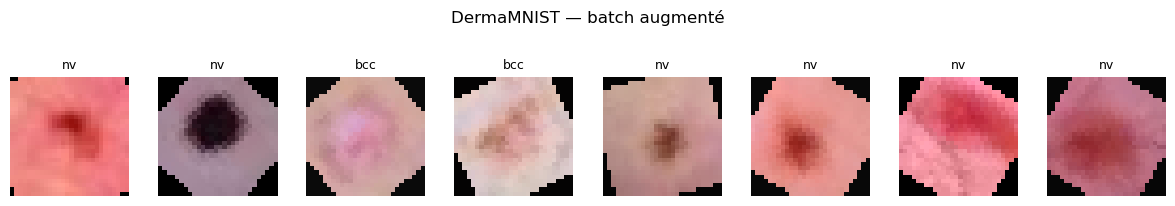

Batch : (128, 3, 28, 28)  mean=0.43  std=1.14


In [2]:
def make_derma(split, transform=None, target_transform=None):
    '''Charge un split DermaMNIST en demandant size=IMG_SIZE (RGB natif),
    avec repli si la version de medmnist ne connaît pas `size`.'''
    kwargs = dict(split=split, root=ROOT, download=True,
                  transform=transform, target_transform=target_transform)
    try:
        return DermaMNIST(size=IMG_SIZE, **kwargs)
    except TypeError:
        return DermaMNIST(**kwargs)

def squeeze_target(t):                       # labels MedMNIST = tableaux shape (1,)
    return int(np.asarray(t).reshape(-1)[0])

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
_MEAN = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
_STD  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

# DermaAugmenter : flips + rotation libre (dermatoscopie sans orientation canonique),
# ColorJitter MODÉRÉ (la couleur est diagnostique).
DermaAugmenter = T_.Compose([
    T_.ToImage(),
    T_.RandomHorizontalFlip(), T_.RandomVerticalFlip(),
    T_.RandomRotation(180),
    T_.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    T_.ToDtype(torch.float32, scale=True),
    T_.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
eval_tf = T_.Compose([
    T_.ToImage(),
    T_.ToDtype(torch.float32, scale=True),
    T_.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def denorm(x):
    '''Tenseur normalisé ImageNet -> [0,1] pour l'affichage.'''
    return (x.detach().cpu() * _STD + _MEAN).clamp(0, 1)

train_aug  = make_derma("train", transform=DermaAugmenter, target_transform=squeeze_target)
train_eval = make_derma("train", transform=eval_tf,        target_transform=squeeze_target)
test_set   = make_derma("test",  transform=eval_tf,        target_transform=squeeze_target)

# split train / validation (10 %) reproductible — la val utilise eval_tf (pas d'augmentation)
g = torch.Generator().manual_seed(SEED)
perm   = torch.randperm(len(train_aug), generator=g)
n_val  = int(0.10 * len(train_aug))
val_idx = perm[:n_val].tolist(); tr_idx = perm[n_val:].tolist()
train_sub = Subset(train_aug,  tr_idx)
val_sub   = Subset(train_eval, val_idx)

train_loader = DataLoader(train_sub, batch_size=BATCH, shuffle=True,  num_workers=0, drop_last=True)
val_loader   = DataLoader(val_sub,   batch_size=256,   shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=256,   shuffle=False, num_workers=0)
print(f"Train : {len(train_sub)}  |  Val : {len(val_sub)}  |  Test : {len(test_set)}")

# Poids de classe = fréquence inverse (sur le train, hors validation)
y_train = np.asarray(train_eval.labels).reshape(-1)[tr_idx]
counts  = np.bincount(y_train, minlength=NUM_CLASSES)
class_weight = torch.tensor(counts.sum() / (NUM_CLASSES * counts), dtype=torch.float32)
print("Effectifs train :", dict(zip(CLASSES_SHORT, counts.tolist())))
print("Poids de classe :", [f"{w:.2f}" for w in class_weight.tolist()])

# aperçu
xb, yb = next(iter(train_loader))
fig, axes = plt.subplots(1, 8, figsize=(12, 1.8))
for i, ax in enumerate(axes):
    ax.imshow(denorm(xb[i]).permute(1, 2, 0).numpy()); ax.axis("off")
    ax.set_title(CLASSES_SHORT[int(yb[i])], fontsize=9)
plt.suptitle("DermaMNIST — batch augmenté", y=1.12); plt.tight_layout(); plt.show()
print(f"Batch : {tuple(xb.shape)}  mean={xb.mean():.2f}  std={xb.std():.2f}")

In [3]:
# ---- Outils communs d'entraînement (réutilisés ViT / Swin / CNN) ----
def count_params(m):
    return sum(p.numel() for p in m.parameters())

@torch.no_grad()
def evaluate_clf(model, loader):
    model.eval(); ys, ps = [], []
    for x, y in loader:
        x = x.to(device).contiguous()
        ps.append(model(x).argmax(1).cpu()); ys.append(y)
    y = torch.cat(ys).numpy(); p = torch.cat(ps).numpy()
    return f1_score(y, p, average="macro"), y, p

def train_classifier(model, epochs, lr, tag, wd=0.05):
    model.to(device)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs * len(train_loader))
    crit  = nn.CrossEntropyLoss(weight=class_weight.to(device))
    hist  = {"tr_loss": [], "va_f1": []}
    best, best_state, t0 = -1.0, None, time.time()
    for ep in range(1, epochs + 1):
        model.train(); run = 0.0
        for x, y in train_loader:
            x = x.to(device).contiguous(); y = y.to(device)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward(); opt.step(); sched.step()
            run += loss.item() * x.size(0)
        f1, _, _ = evaluate_clf(model, val_loader)
        hist["tr_loss"].append(run / len(train_sub)); hist["va_f1"].append(f1)
        if f1 > best:
            best = f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"[{tag}] ep {ep:2d}/{epochs}  loss {hist['tr_loss'][-1]:.3f}  val macro-F1 {f1:.3f}")
    model.load_state_dict(best_state)
    print(f"[{tag}] meilleure val macro-F1 = {best:.3f}  "
          f"({time.time()-t0:.0f}s, {count_params(model)/1e6:.2f}M params)")
    return hist, best

@torch.no_grad()
def throughput(model, n_batches=20, bs=128):
    '''Images/seconde en inférence (mesure synchronisée).'''
    model.eval()
    x = torch.randn(bs, 3, IMG_SIZE, IMG_SIZE, device=device)
    for _ in range(3): model(x)              # warm-up
    sync(); t0 = time.time()
    for _ in range(n_batches): model(x)
    sync()
    return n_batches * bs / (time.time() - t0)

## Partie III — Patch embedding *from scratch*

Découper l'image en patchs $P\times P$ **non chevauchants** puis les projeter linéairement = une **convolution de noyau et de pas $P$**. C'est strictement équivalent à `nn.Unfold` (extraction des patchs) suivi d'un produit matriciel — on le **vérifie numériquement**. La bibliothèque `einops` l'écrit en une ligne (`rearrange`), mais `Conv2d` est la forme canonique de la plupart des implémentations (ViT, Swin, SegFormer).

N patchs = 16 | tokens (2, 16, 128)
Conv2d == Unfold : True


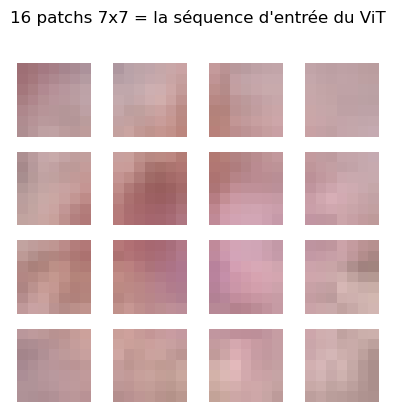

In [4]:
class PatchEmbed(nn.Module):
    '''Image (B,C,H,W) -> séquence de tokens (B, N, dim), N=(H/P)*(W/P).'''
    def __init__(self, img_size=IMG_SIZE, patch=PATCH, in_ch=3, dim=128):
        super().__init__()
        self.n_patches = (img_size // patch) ** 2
        self.proj = nn.Conv2d(in_ch, dim, kernel_size=patch, stride=patch)
    def forward(self, x):
        x = self.proj(x)                     # (B, dim, H/P, W/P)
        return x.flatten(2).transpose(1, 2)  # (B, N, dim)

# --- Équivalence Conv2d  ==  Unfold + produit matriciel ---
pe = PatchEmbed(dim=128)
x  = torch.randn(2, 3, 28, 28)
out_conv = pe(x)
W = pe.proj.weight.view(128, -1)             # (dim, C*P*P)
unf = F.unfold(x, kernel_size=PATCH, stride=PATCH).transpose(1, 2)   # (B, N, C*P*P)
out_unf = unf @ W.t() + pe.proj.bias
print(f"N patchs = {pe.n_patches} | tokens {tuple(out_conv.shape)}")
print(f"Conv2d == Unfold : {torch.allclose(out_conv, out_unf, atol=1e-4)}")

# --- Visualisation : une image -> ses 16 patchs 7x7 ---
img_u8 = train_eval.imgs[0]                                   # (28,28,3) uint8
grid   = img_u8.reshape(4, 7, 4, 7, 3).transpose(0, 2, 1, 3, 4).reshape(16, 7, 7, 3)
fig, axes = plt.subplots(4, 4, figsize=(4, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(grid[i]); ax.axis("off")
plt.suptitle("16 patchs 7x7 = la séquence d'entrée du ViT", y=1.02)
plt.tight_layout(); plt.show()

## Partie IV — Self-attention & multi-têtes *from scratch*

On code la formule $\mathrm{softmax}(QK^\top/\sqrt{d_k})V$, on **reproduit l'exemple numérique** de la Partie I.2 (sortie attendue $(0.670, 0.660)$), puis on assemble l'attention **multi-têtes** — validée contre la primitive optimisée `F.scaled_dot_product_attention` de PyTorch.

In [5]:
def scaled_dot_product_attention(q, k, v, mask=None):
    '''q,k,v : (..., n, d_k). Retourne (sortie, poids d'attention).'''
    d_k = q.size(-1)
    scores = q @ k.transpose(-2, -1) / math.sqrt(d_k)
    if mask is not None:
        scores = scores + mask
    attn = scores.softmax(dim=-1)
    return attn @ v, attn

# --- Reproduction de l'exemple numérique I.2 ---
q = torch.tensor([[1., 0.]])
k = torch.tensor([[1., 0.], [0., 1.]])
v = torch.tensor([[1., 0.], [0., 2.]])
o, a = scaled_dot_product_attention(q, k, v)
print(f"poids a = {a.numpy().round(3).tolist()}   (attendu [[0.670, 0.330]])")
print(f"sortie o1 = {o.numpy().round(3).tolist()}   (attendu [[0.670, 0.660]])")
assert torch.allclose(o, torch.tensor([[0.670, 0.660]]), atol=2e-3)

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        assert dim % heads == 0
        self.heads, self.d_k = heads, dim // heads
        self.qkv  = nn.Linear(dim, 3 * dim)
        self.proj = nn.Linear(dim, dim)
    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.heads, self.d_k).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]                 # (B, h, N, d_k)
        out, attn = scaled_dot_product_attention(q, k, v)
        out = out.transpose(1, 2).reshape(B, N, D)       # fusion des têtes
        return self.proj(out), attn.mean(1)              # carte moyennée sur les têtes

# --- Validation contre la primitive PyTorch ---
torch.manual_seed(0)
qh = torch.randn(2, 4, 17, 32); kh = torch.randn(2, 4, 17, 32); vh = torch.randn(2, 4, 17, 32)
mine, _ = scaled_dot_product_attention(qh, kh, vh)
ref     = F.scaled_dot_product_attention(qh, kh, vh)
print(f"\nmaison == F.scaled_dot_product_attention : {torch.allclose(mine, ref, atol=1e-5)}")
mha = MultiHeadSelfAttention(128, 4)
y, att = mha(torch.randn(2, 16, 128))
print(f"MHSA : sortie {tuple(y.shape)} | attention {tuple(att.shape)} | somme par ligne = {att.sum(-1).mean():.3f}")

poids a = [[0.6700000166893005, 0.33000001311302185]]   (attendu [[0.670, 0.330]])
sortie o1 = [[0.6700000166893005, 0.6600000262260437]]   (attendu [[0.670, 0.660]])

maison == F.scaled_dot_product_attention : True
MHSA : sortie (2, 16, 128) | attention (2, 16, 16) | somme par ligne = 1.000


## Partie V — Vision Transformer *from scratch*

Assemblage : `PatchEmbed` → préfixe `[CLS]` → ajout de $E_{\text{pos}}$ appris → $L$ **blocs pré-norm** (MHSA + MLP/GELU, résiduels) → `LayerNorm` → tête linéaire sur le token `[CLS]`. Chaque bloc **mémorise sa carte d'attention** (`last_attn`) pour la Partie VI.

In [6]:
class TransformerBlock(nn.Module):
    '''Bloc encodeur pré-norm : z' = z + MHSA(LN z) ; z = z' + MLP(LN z').'''
    def __init__(self, dim, heads, mlp_ratio=4, drop=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = MultiHeadSelfAttention(dim, heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_ratio * dim), nn.GELU(), nn.Dropout(drop),
            nn.Linear(mlp_ratio * dim, dim), nn.Dropout(drop))
        self.last_attn = None
    def forward(self, x):
        a, attn = self.attn(self.norm1(x))
        self.last_attn = attn
        x = x + a
        return x + self.mlp(self.norm2(x))

class ViT(nn.Module):
    def __init__(self, img=IMG_SIZE, patch=PATCH, in_ch=3, dim=128,
                 depth=6, heads=4, n_classes=NUM_CLASSES, drop=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(img, patch, in_ch, dim)
        N = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, N + 1, dim))
        self.drop   = nn.Dropout(drop)
        self.blocks = nn.ModuleList([TransformerBlock(dim, heads, drop=drop) for _ in range(depth)])
        self.norm   = nn.LayerNorm(dim)
        self.head   = nn.Linear(dim, n_classes)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        x = torch.cat([self.cls_token.expand(B, -1, -1), x], dim=1) + self.pos_embed
        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)
        return self.head(self.norm(x)[:, 0])      # décision portée par le token [CLS]

vit = ViT()
print(vit)
print(f"\nViT from scratch : {count_params(vit)/1e6:.2f}M paramètres "
      f"(dim=128, depth=6, heads=4, {vit.patch_embed.n_patches} patchs + [CLS])")

ViT(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 128, kernel_size=(7, 7), stride=(7, 7))
  )
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=128, out_features=384, bias=True)
        (proj): Linear(in_features=128, out_features=128, bias=True)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=128, out_features=7, bias=True)
)

ViT from scratch : 1.21M paramètres (dim=128, depth=6, 

In [7]:
hist_vit, _ = train_classifier(vit, EPOCHS_VIT, lr=3e-4, tag="ViT")

[ViT] ep  1/16  loss 1.888  val macro-F1 0.190
[ViT] ep  2/16  loss 1.728  val macro-F1 0.206
[ViT] ep  3/16  loss 1.671  val macro-F1 0.247
[ViT] ep  4/16  loss 1.567  val macro-F1 0.254
[ViT] ep  5/16  loss 1.510  val macro-F1 0.310
[ViT] ep  6/16  loss 1.448  val macro-F1 0.297
[ViT] ep  7/16  loss 1.408  val macro-F1 0.329
[ViT] ep  8/16  loss 1.399  val macro-F1 0.383
[ViT] ep  9/16  loss 1.395  val macro-F1 0.341
[ViT] ep 10/16  loss 1.338  val macro-F1 0.381
[ViT] ep 11/16  loss 1.349  val macro-F1 0.394
[ViT] ep 12/16  loss 1.320  val macro-F1 0.366
[ViT] ep 13/16  loss 1.282  val macro-F1 0.379
[ViT] ep 14/16  loss 1.277  val macro-F1 0.387
[ViT] ep 15/16  loss 1.252  val macro-F1 0.384
[ViT] ep 16/16  loss 1.263  val macro-F1 0.385
[ViT] meilleure val macro-F1 = 0.394  (55s, 1.21M params)


ViT — macro-F1 TEST = 0.398

              precision    recall  f1-score   support

       akiec      0.178     0.576     0.272        66
         bcc      0.237     0.505     0.323       103
         bkl      0.332     0.518     0.405       220
          df      0.140     0.261     0.182        23
         mel      0.342     0.422     0.378       223
          nv      0.929     0.604     0.732      1341
        vasc      0.425     0.586     0.493        29

    accuracy                          0.564      2005
   macro avg      0.369     0.496     0.398      2005
weighted avg      0.722     0.564     0.611      2005



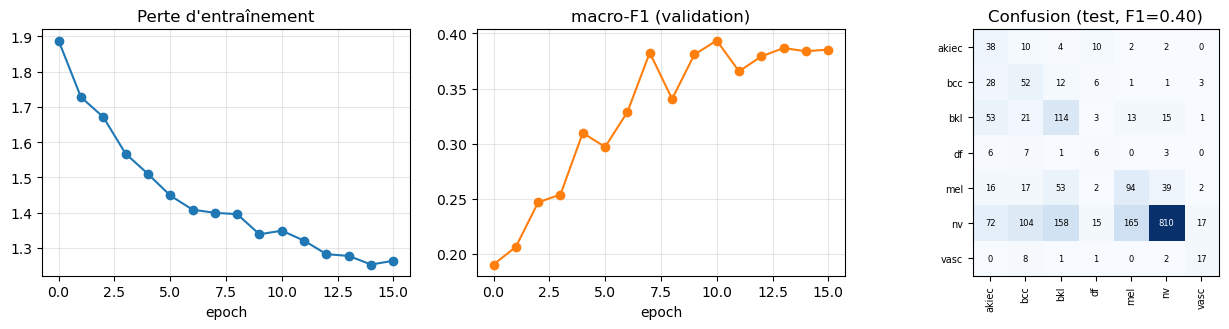

In [8]:
# courbes + évaluation TEST finale
f1_test, y_true, y_pred = evaluate_clf(vit, test_loader)
print(f"ViT — macro-F1 TEST = {f1_test:.3f}\n")
print(classification_report(y_true, y_pred, target_names=CLASSES_SHORT, digits=3, zero_division=0))

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].plot(hist_vit["tr_loss"], marker="o"); ax[0].set_title("Perte d'entraînement")
ax[0].set_xlabel("epoch"); ax[0].grid(alpha=.3)
ax[1].plot(hist_vit["va_f1"], marker="o", color="C1"); ax[1].set_title("macro-F1 (validation)")
ax[1].set_xlabel("epoch"); ax[1].grid(alpha=.3)
cm = confusion_matrix(y_true, y_pred)
im = ax[2].imshow(cm, cmap="Blues"); ax[2].set_title(f"Confusion (test, F1={f1_test:.2f})")
ax[2].set_xticks(range(7)); ax[2].set_xticklabels(CLASSES_SHORT, rotation=90, fontsize=7)
ax[2].set_yticks(range(7)); ax[2].set_yticklabels(CLASSES_SHORT, fontsize=7)
for (i, j), z in np.ndenumerate(cm):
    ax[2].text(j, i, z, ha="center", va="center", fontsize=6,
               color="white" if z > cm.max()/2 else "black")
plt.tight_layout(); plt.show()

## Partie VI — Visualiser l'attention (*attention rollout*)

Les Transformers offrent une interprétabilité **native** : la carte d'attention du token `[CLS]` vers les patchs. Mais l'attention d'une seule couche ignore les **résiduelles**. L'*attention rollout* (Abnar & Zenati, 2020) propage l'attention à travers les $L$ couches en ajoutant l'identité (le résidu) puis en multipliant les matrices :
$$\tilde A_\ell = \tfrac12 A_\ell + \tfrac12 I, \qquad R = \tilde A_L \cdots \tilde A_1 .$$
La ligne `[CLS]` de $R$, repliée en grille $4\times4$ et suréchantillonnée, indique **où le modèle regarde**. À comparer au Grad-CAM du Module 2.

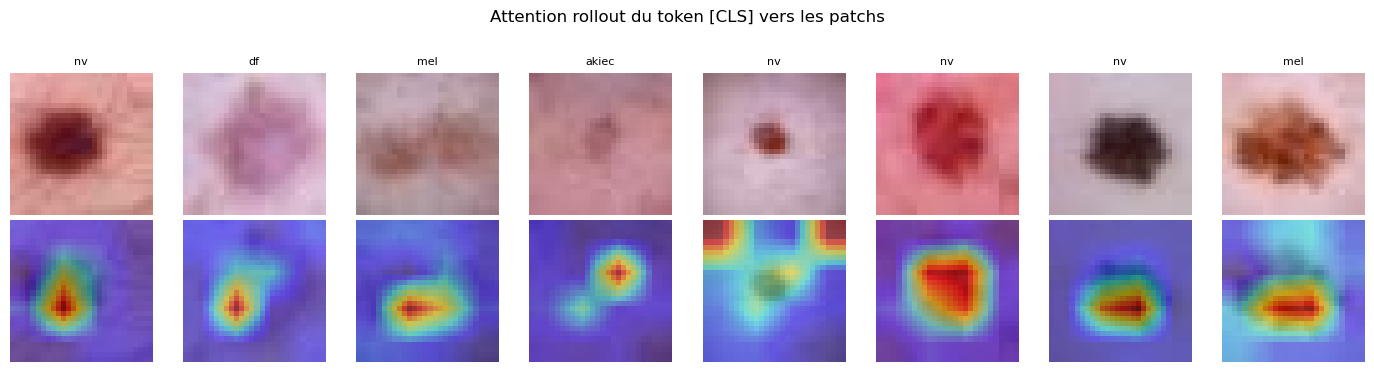

In [9]:
@torch.no_grad()
def attention_rollout(model, x):
    model.eval(); _ = model(x)
    n = model.patch_embed.n_patches + 1
    R = torch.eye(n, device=x.device).unsqueeze(0).expand(x.size(0), -1, -1).clone()
    for blk in model.blocks:
        A = blk.last_attn + torch.eye(n, device=x.device).unsqueeze(0)
        A = A / A.sum(-1, keepdim=True)
        R = A @ R
    g = int(model.patch_embed.n_patches ** 0.5)
    return R[:, 0, 1:].reshape(-1, g, g)          # [CLS] -> patchs, en grille

xb, yb = next(iter(test_loader))
xb = xb.to(device).contiguous()
roll = attention_rollout(vit, xb[:8]).cpu()

fig, axes = plt.subplots(2, 8, figsize=(14, 3.6))
for i in range(8):
    base = denorm(xb[i]).permute(1, 2, 0).numpy()
    heat = F.interpolate(roll[i][None, None], size=(28, 28),
                         mode="bilinear", align_corners=False)[0, 0].numpy()
    heat = (heat - heat.min()) / (np.ptp(heat) + 1e-8)
    axes[0, i].imshow(base); axes[0, i].set_title(CLASSES_SHORT[int(yb[i])], fontsize=8)
    axes[1, i].imshow(base); axes[1, i].imshow(heat, cmap="jet", alpha=0.5)
    axes[0, i].axis("off"); axes[1, i].axis("off")
axes[0, 0].set_ylabel("image"); axes[1, 0].set_ylabel("rollout")
plt.suptitle("Attention rollout du token [CLS] vers les patchs", y=1.02)
plt.tight_layout(); plt.show()

## Partie VII — Swin Transformer *from scratch*

On code le cœur de Swin : **partition en fenêtres** $M\times M$, **W-MSA** (attention intra-fenêtre) avec **biais de position relatif** appris, puis **SW-MSA** (fenêtres décalées par `torch.roll` + **masque** d'attention empêchant les patchs recollés par le décalage cyclique de communiquer). Le **patch merging** $2\times2$ divise la résolution par 2 et double les canaux. On vérifie d'abord le gain de complexité **64×** annoncé en I.5, puis on entraîne un **Swin-Tiny** que l'on compare au ViT.

In [10]:
# --- Vérification du coût : étage 1 Swin (56x56 patchs, C=96, M=7) ---
hw, C, M = 56 * 56, 96, 7
omega_msa   = 4*hw*C**2 + 2*hw**2*C
omega_wmsa  = 4*hw*C**2 + 2*M**2*hw*C
print(f"Terme d'attention global  2(hw)^2 C = {2*hw**2*C:.2e}")
print(f"Terme d'attention fenêtré 2 M^2 hw C = {2*M**2*hw*C:.2e}")
print(f"Rapport (hw)/M^2 = {hw/M**2:.0f}x   |   Omega(MSA)={omega_msa:.2e}  vs  Omega(W-MSA)={omega_wmsa:.2e}")

def window_partition(x, M):                  # (B,H,W,C) -> (nW*B, M*M, C)
    B, H, W, C = x.shape
    x = x.view(B, H//M, M, W//M, M, C).permute(0, 1, 3, 2, 4, 5).contiguous()
    return x.view(-1, M*M, C)

def window_reverse(w, M, H, W):              # (nW*B, M*M, C) -> (B,H,W,C)
    C = w.shape[-1]; B = int(w.shape[0] / (H*W/M/M))
    x = w.view(B, H//M, W//M, M, M, C).permute(0, 1, 3, 2, 4, 5).contiguous()
    return x.view(B, H, W, C)

class WindowAttention(nn.Module):
    def __init__(self, dim, M, heads):
        super().__init__()
        self.heads, self.d_k, self.M = heads, dim // heads, M
        self.scale = self.d_k ** -0.5
        self.qkv = nn.Linear(dim, 3*dim); self.proj = nn.Linear(dim, dim)
        self.rel_bias = nn.Parameter(torch.zeros((2*M-1)*(2*M-1), heads))
        coords = torch.stack(torch.meshgrid(torch.arange(M), torch.arange(M),
                                            indexing="ij")).flatten(1)        # (2, M*M)
        rel = (coords[:, :, None] - coords[:, None, :]).permute(1, 2, 0).contiguous()
        rel[:, :, 0] += M-1; rel[:, :, 1] += M-1; rel[:, :, 0] *= 2*M-1
        self.register_buffer("rel_idx", rel.sum(-1))                          # (M*M, M*M)
        nn.init.trunc_normal_(self.rel_bias, std=0.02)
    def forward(self, x, mask=None):
        Bn, N, D = x.shape
        qkv = self.qkv(x).reshape(Bn, N, 3, self.heads, self.d_k).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        bias = self.rel_bias[self.rel_idx.view(-1)].view(N, N, -1).permute(2, 0, 1)
        attn = attn + bias.unsqueeze(0)                                       # biais de position relatif
        if mask is not None:                                                  # masque SW-MSA
            nW = mask.shape[0]
            attn = attn.view(Bn//nW, nW, self.heads, N, N) + mask[None, :, None]
            attn = attn.view(-1, self.heads, N, N)
        attn = attn.softmax(-1)
        out = (attn @ v).transpose(1, 2).reshape(Bn, N, D)
        return self.proj(out)

class SwinBlock(nn.Module):
    def __init__(self, dim, res, M, heads, shift, mlp_ratio=4):
        super().__init__()
        self.res = res
        self.M = min(M, res)
        self.shift = 0 if res <= M else shift          # pas de décalage si une seule fenêtre
        self.norm1 = nn.LayerNorm(dim); self.attn = WindowAttention(dim, self.M, heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, mlp_ratio*dim), nn.GELU(),
                                 nn.Linear(mlp_ratio*dim, dim))
        if self.shift > 0:                              # masque d'attention des fenêtres décalées
            img = torch.zeros(1, res, res, 1); cnt = 0
            for hs in (slice(0,-self.M), slice(-self.M,-self.shift), slice(-self.shift,None)):
                for ws in (slice(0,-self.M), slice(-self.M,-self.shift), slice(-self.shift,None)):
                    img[:, hs, ws, :] = cnt; cnt += 1
            mw = window_partition(img, self.M).view(-1, self.M*self.M)
            am = mw[:, None] - mw[:, :, None]
            am = am.masked_fill(am != 0, -100.0).masked_fill(am == 0, 0.0)
            self.register_buffer("attn_mask", am)
        else:
            self.attn_mask = None
    def forward(self, x):                               # (B, res*res, C)
        H = W = self.res; B, _, Cc = x.shape
        skip = x
        x = self.norm1(x).view(B, H, W, Cc)
        if self.shift > 0:
            x = torch.roll(x, (-self.shift, -self.shift), dims=(1, 2))
        x = window_partition(x, self.M)
        x = self.attn(x, self.attn_mask)
        x = window_reverse(x, self.M, H, W)
        if self.shift > 0:
            x = torch.roll(x, (self.shift, self.shift), dims=(1, 2))
        x = skip + x.view(B, H*W, Cc)
        return x + self.mlp(self.norm2(x))

class PatchMerging(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.norm = nn.LayerNorm(4*dim); self.reduce = nn.Linear(4*dim, 2*dim, bias=False)
    def forward(self, x, H, W):
        B, _, C = x.shape; x = x.view(B, H, W, C)
        x = torch.cat([x[:, 0::2, 0::2], x[:, 1::2, 0::2],
                       x[:, 0::2, 1::2], x[:, 1::2, 1::2]], -1).reshape(B, -1, 4*C)
        return self.reduce(self.norm(x))

Terme d'attention global  2(hw)^2 C = 1.89e+09
Terme d'attention fenêtré 2 M^2 hw C = 2.95e+07
Rapport (hw)/M^2 = 64x   |   Omega(MSA)=2.00e+09  vs  Omega(W-MSA)=1.45e+08


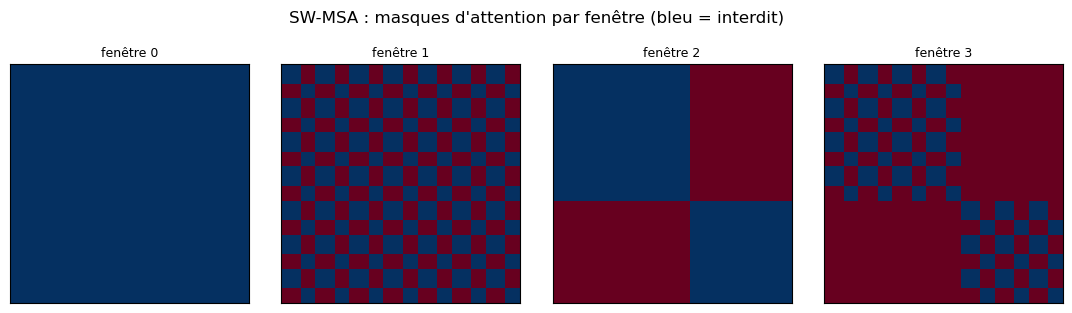

Swin-Tiny from scratch : 0.30M paramètres
[Swin] ep  1/12  loss 1.817  val macro-F1 0.164
[Swin] ep  2/12  loss 1.659  val macro-F1 0.269
[Swin] ep  3/12  loss 1.562  val macro-F1 0.288
[Swin] ep  4/12  loss 1.483  val macro-F1 0.324
[Swin] ep  5/12  loss 1.374  val macro-F1 0.332
[Swin] ep  6/12  loss 1.364  val macro-F1 0.367
[Swin] ep  7/12  loss 1.314  val macro-F1 0.346
[Swin] ep  8/12  loss 1.284  val macro-F1 0.394
[Swin] ep  9/12  loss 1.231  val macro-F1 0.387
[Swin] ep 10/12  loss 1.226  val macro-F1 0.390
[Swin] ep 11/12  loss 1.218  val macro-F1 0.378
[Swin] ep 12/12  loss 1.223  val macro-F1 0.381
[Swin] meilleure val macro-F1 = 0.394  (50s, 0.30M params)
Swin — macro-F1 TEST = 0.400


In [11]:
# --- Le masque SW-MSA rendu visible (étage à 14x14 patchs, M=7, décalage 3) ---
blk_shift = SwinBlock(48, res=14, M=7, heads=3, shift=3)
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for w in range(4):
    axes[w].imshow(blk_shift.attn_mask[w].numpy(), cmap="RdBu", vmin=-100, vmax=0)
    axes[w].set_title(f"fenêtre {w}", fontsize=9); axes[w].set_xticks([]); axes[w].set_yticks([])
plt.suptitle("SW-MSA : masques d'attention par fenêtre (bleu = interdit)", y=1.03)
plt.tight_layout(); plt.show()

class SwinTiny(nn.Module):
    '''2 étages : 14x14 (dim 48) -> merge -> 7x7 (dim 96).'''
    def __init__(self, n_classes=NUM_CLASSES, dim=48):
        super().__init__()
        self.embed = nn.Conv2d(3, dim, kernel_size=2, stride=2)              # 28 -> 14
        self.stage1 = nn.ModuleList([SwinBlock(dim, 14, 7, heads=3, shift=0),
                                     SwinBlock(dim, 14, 7, heads=3, shift=3)])
        self.merge  = PatchMerging(dim)                                      # 14 -> 7, dim -> 2*dim
        self.stage2 = nn.ModuleList([SwinBlock(2*dim, 7, 7, heads=6, shift=0),
                                     SwinBlock(2*dim, 7, 7, heads=6, shift=3)])
        self.norm = nn.LayerNorm(2*dim); self.head = nn.Linear(2*dim, n_classes)
    def forward(self, x):
        x = self.embed(x).flatten(2).transpose(1, 2)                        # (B,196,48)
        for b in self.stage1: x = b(x)
        x = self.merge(x, 14, 14)                                           # (B,49,96)
        for b in self.stage2: x = b(x)
        return self.head(self.norm(x).mean(1))

swin = SwinTiny()
print(f"Swin-Tiny from scratch : {count_params(swin)/1e6:.2f}M paramètres")
hist_swin, _ = train_classifier(swin, EPOCHS_SWIN, lr=3e-4, tag="Swin")
f1_swin, _, _ = evaluate_clf(swin, test_loader)
print(f"Swin — macro-F1 TEST = {f1_swin:.3f}")

## Partie VIII — SegFormer *from scratch* : segmentation de lésions

On illustre l'architecture **SegFormer** sur une tâche de **segmentation binaire** (lésion vs peau). Faute d'annotations expertes (type ISIC) dans MedMNIST, on fabrique des **pseudo-masques** par **seuillage d'Otsu** sur la luminance — la lésion étant la région la plus sombre. *Ce sont des cibles automatiques approximatives, suffisantes pour démontrer l'architecture, pas une vérité-terrain clinique.*

Briques codées : **OverlapPatchEmbed** (conv chevauchante, encodeur hiérarchique), **EfficientSelfAttention** ($K,V$ sous-échantillonnés d'un facteur $R$), **Mix-FFN** (Conv $3\times3$ *depthwise*, sans encodage positionnel), et un **décodeur tout-MLP** fusionnant les échelles.

Segmentation — train 2500 / val 600 | couverture lésion moyenne = 0.26


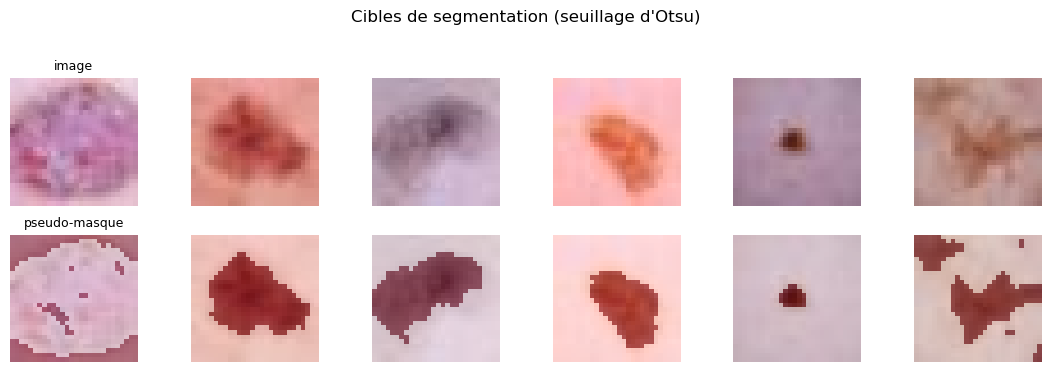

In [12]:
from skimage.filters import threshold_otsu
from skimage.morphology import binary_closing, disk, remove_small_holes

def pseudo_mask(rgb):
    '''Pseudo-masque de lésion (Otsu sur la luminance) -> float32 HxW dans {0,1}.'''
    gray = (0.299*rgb[..., 0] + 0.587*rgb[..., 1] + 0.114*rgb[..., 2]) / 255.0
    try:    thr = threshold_otsu(gray)
    except Exception: thr = gray.mean()
    m = gray < thr                          # la lésion est plus sombre
    if m.mean() > 0.5: m = ~m               # la lésion est minoritaire
    m = remove_small_holes(binary_closing(m, disk(1)), 16)
    return m.astype(np.float32)

class LesionSeg(Dataset):
    def __init__(self, base, indices, tf):
        idx = np.asarray(indices)
        self.imgs  = base.imgs[idx]                                  # (n,28,28,3) uint8
        self.masks = np.stack([pseudo_mask(im) for im in self.imgs])  # (n,28,28)
        self.tf = tf
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        return self.tf(self.imgs[i]), torch.from_numpy(self.masks[i])[None]

seg_tr_idx, seg_va_idx = tr_idx[:2500], val_idx[:600]
seg_train = LesionSeg(train_eval, seg_tr_idx, eval_tf)
seg_val   = LesionSeg(train_eval, seg_va_idx, eval_tf)
seg_train_loader = DataLoader(seg_train, batch_size=64, shuffle=True,  num_workers=0)
seg_val_loader   = DataLoader(seg_val,   batch_size=128, shuffle=False, num_workers=0)
print(f"Segmentation — train {len(seg_train)} / val {len(seg_val)} | "
      f"couverture lésion moyenne = {seg_train.masks.mean():.2f}")

fig, axes = plt.subplots(2, 6, figsize=(11, 3.6))
for i in range(6):
    axes[0, i].imshow(seg_train.imgs[i]); axes[0, i].axis("off")
    axes[1, i].imshow(seg_train.imgs[i]); axes[1, i].imshow(seg_train.masks[i], cmap="Reds", alpha=0.45)
    axes[1, i].axis("off")
axes[0, 0].set_title("image", fontsize=9); axes[1, 0].set_title("pseudo-masque", fontsize=9)
plt.suptitle("Cibles de segmentation (seuillage d'Otsu)", y=1.02); plt.tight_layout(); plt.show()

In [13]:
class OverlapPatchEmbed(nn.Module):
    def __init__(self, ci, co, k, s):
        super().__init__(); self.proj = nn.Conv2d(ci, co, k, s, k//2); self.norm = nn.LayerNorm(co)
    def forward(self, x):
        x = self.proj(x); _, _, H, W = x.shape
        return self.norm(x.flatten(2).transpose(1, 2)), H, W

class EfficientSelfAttention(nn.Module):
    def __init__(self, dim, heads, R):
        super().__init__()
        self.heads, self.d_k, self.R = heads, dim // heads, R
        self.scale = self.d_k ** -0.5
        self.q = nn.Linear(dim, dim); self.kv = nn.Linear(dim, 2*dim); self.proj = nn.Linear(dim, dim)
        if R > 1:
            self.sr = nn.Conv2d(dim, dim, R, R); self.norm = nn.LayerNorm(dim)
    def forward(self, x, H, W):
        B, N, D = x.shape
        q = self.q(x).reshape(B, N, self.heads, self.d_k).permute(0, 2, 1, 3)
        if self.R > 1:
            xr = x.permute(0, 2, 1).reshape(B, D, H, W)
            xr = self.sr(xr).reshape(B, D, -1).permute(0, 2, 1)
            x = self.norm(xr)                                  # K, V sur séquence réduite
        kv = self.kv(x).reshape(B, -1, 2, self.heads, self.d_k).permute(2, 0, 3, 1, 4)
        k, v = kv[0], kv[1]
        attn = ((q @ k.transpose(-2, -1)) * self.scale).softmax(-1)
        out = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj(out)

class MixFFN(nn.Module):
    '''Conv 3x3 depthwise DANS le MLP -> remplace l'encodage positionnel.'''
    def __init__(self, dim, hidden):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden)
        self.dw  = nn.Conv2d(hidden, hidden, 3, 1, 1, groups=hidden)
        self.fc2 = nn.Linear(hidden, dim)
    def forward(self, x, H, W):
        x = self.fc1(x); B, N, C = x.shape
        x = self.dw(x.transpose(1, 2).view(B, C, H, W)).flatten(2).transpose(1, 2)
        return self.fc2(F.gelu(x))

class MiTBlock(nn.Module):
    def __init__(self, dim, heads, R, mlp_ratio=4):
        super().__init__()
        self.n1 = nn.LayerNorm(dim); self.attn = EfficientSelfAttention(dim, heads, R)
        self.n2 = nn.LayerNorm(dim); self.ffn  = MixFFN(dim, mlp_ratio*dim)
    def forward(self, x, H, W):
        x = x + self.attn(self.n1(x), H, W)
        return x + self.ffn(self.n2(x), H, W)

class SegFormerMini(nn.Module):
    '''Encodeur MiT à 2 étages + décodeur tout-MLP, sortie 1 canal (logits).'''
    def __init__(self, dims=(32, 64), heads=(1, 2), Rs=(2, 1), dec=64):
        super().__init__()
        self.pe1 = OverlapPatchEmbed(3, dims[0], 7, 4)        # 28 -> 7
        self.b1  = MiTBlock(dims[0], heads[0], Rs[0])
        self.pe2 = OverlapPatchEmbed(dims[0], dims[1], 3, 2)  # 7 -> 4
        self.b2  = MiTBlock(dims[1], heads[1], Rs[1])
        self.lin = nn.ModuleList([nn.Conv2d(d, dec, 1) for d in dims])
        self.fuse = nn.Conv2d(2*dec, dec, 1); self.classifier = nn.Conv2d(dec, 1, 1)
    def forward(self, x):
        H, W = x.shape[-2:]; B = x.size(0); feats = []
        t, h, w = self.pe1(x); t = self.b1(t, h, w)
        feats.append(t.permute(0, 2, 1).reshape(B, -1, h, w))
        t, h, w = self.pe2(feats[-1]); t = self.b2(t, h, w)
        feats.append(t.permute(0, 2, 1).reshape(B, -1, h, w))
        dh, dw = H//4, W//4
        ups = [F.interpolate(l(f), size=(dh, dw), mode="bilinear", align_corners=False)
               for f, l in zip(feats, self.lin)]
        y = self.classifier(self.fuse(torch.cat(ups, 1)))
        return F.interpolate(y, size=(H, W), mode="bilinear", align_corners=False)

def dice_loss(logits, target, eps=1.0):
    p = torch.sigmoid(logits)
    num = 2*(p*target).sum((1, 2, 3)) + eps
    den = (p + target).sum((1, 2, 3)) + eps
    return (1 - num/den).mean()

@torch.no_grad()
def seg_metrics(model, loader, thr=0.5):
    model.eval(); inter = union = dn = dd = 0.0
    for x, m in loader:
        x = x.to(device).contiguous(); m = m.to(device)
        p = (torch.sigmoid(model(x)) > thr).float()
        inter += (p*m).sum().item(); union += ((p + m) >= 1).float().sum().item()
        dn += 2*(p*m).sum().item(); dd += (p + m).sum().item()
    return inter/union, dn/dd                              # IoU, Dice

segm = SegFormerMini().to(device)
print(f"SegFormer-mini : {count_params(segm)/1e6:.2f}M paramètres")
opt = torch.optim.AdamW(segm.parameters(), lr=6e-4, weight_decay=1e-2)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_SEG*len(seg_train_loader))
t0 = time.time(); best = -1; best_state = None
for ep in range(1, EPOCHS_SEG + 1):
    segm.train()
    for x, m in seg_train_loader:
        x = x.to(device).contiguous(); m = m.to(device)
        opt.zero_grad()
        out = segm(x)
        loss = F.binary_cross_entropy_with_logits(out, m) + dice_loss(out, m)
        loss.backward(); opt.step(); sched.step()
    iou, dice = seg_metrics(segm, seg_val_loader)
    if dice > best: best = dice; best_state = {k: v.detach().cpu().clone() for k, v in segm.state_dict().items()}
    print(f"[SegFormer] ep {ep:2d}/{EPOCHS_SEG}  val IoU {iou:.3f}  Dice {dice:.3f}")
segm.load_state_dict(best_state)
iou, dice = seg_metrics(segm, seg_val_loader)
print(f"[SegFormer] meilleure val  IoU {iou:.3f}  Dice {dice:.3f}  ({time.time()-t0:.0f}s)")

SegFormer-mini : 0.11M paramètres
[SegFormer] ep  1/14  val IoU 0.570  Dice 0.726
[SegFormer] ep  2/14  val IoU 0.579  Dice 0.733
[SegFormer] ep  3/14  val IoU 0.599  Dice 0.749
[SegFormer] ep  4/14  val IoU 0.578  Dice 0.733
[SegFormer] ep  5/14  val IoU 0.647  Dice 0.786
[SegFormer] ep  6/14  val IoU 0.651  Dice 0.789
[SegFormer] ep  7/14  val IoU 0.661  Dice 0.796
[SegFormer] ep  8/14  val IoU 0.655  Dice 0.792
[SegFormer] ep  9/14  val IoU 0.669  Dice 0.802
[SegFormer] ep 10/14  val IoU 0.670  Dice 0.803
[SegFormer] ep 11/14  val IoU 0.668  Dice 0.801
[SegFormer] ep 12/14  val IoU 0.673  Dice 0.804
[SegFormer] ep 13/14  val IoU 0.674  Dice 0.805
[SegFormer] ep 14/14  val IoU 0.673  Dice 0.805
[SegFormer] meilleure val  IoU 0.674  Dice 0.805  (9s)


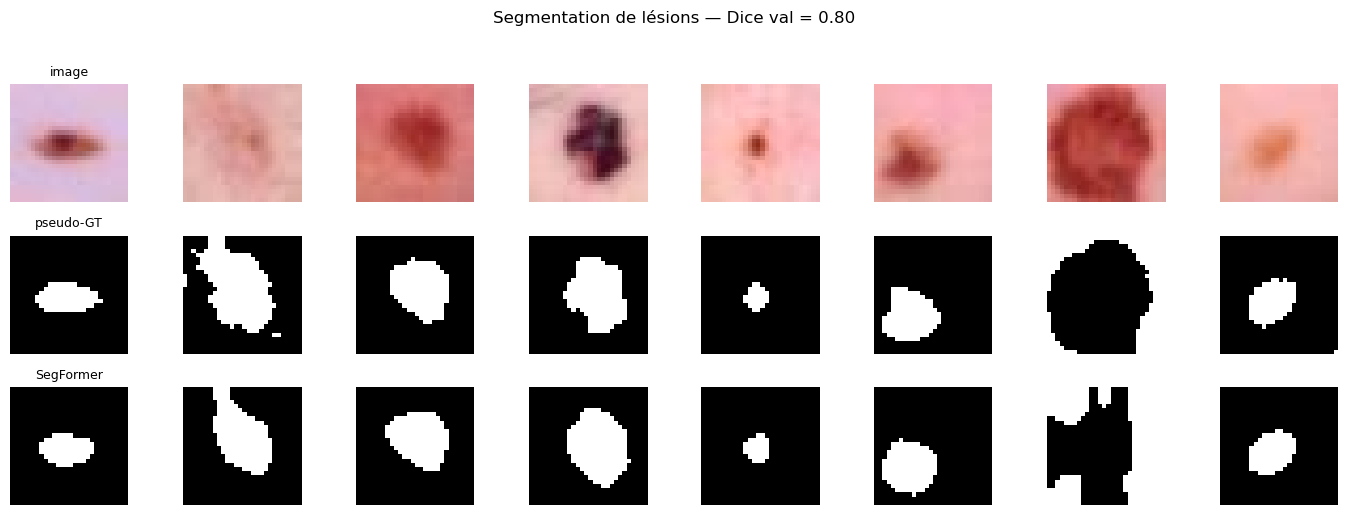

In [14]:
# Prédictions de segmentation
xb, mb = next(iter(seg_val_loader))
with torch.no_grad():
    pb = (torch.sigmoid(segm(xb.to(device).contiguous())) > 0.5).float().cpu()
fig, axes = plt.subplots(3, 8, figsize=(14, 5))
for i in range(8):
    axes[0, i].imshow(denorm(xb[i]).permute(1, 2, 0).numpy())
    axes[1, i].imshow(mb[i, 0], cmap="gray")
    axes[2, i].imshow(pb[i, 0], cmap="gray")
    for r in range(3): axes[r, i].axis("off")
axes[0, 0].set_title("image", fontsize=9); axes[1, 0].set_title("pseudo-GT", fontsize=9)
axes[2, 0].set_title("SegFormer", fontsize=9)
plt.suptitle(f"Segmentation de lésions — Dice val = {dice:.2f}", y=1.02)
plt.tight_layout(); plt.show()

## Partie IX — CNN vs ViT : biais inductif, paramètres, débit

Pour trancher la **règle pratique** de I.7, on entraîne un **petit CNN** dans des conditions **identiques** (mêmes données, même budget, même perte pondérée) et on compare au ViT et au Swin : **macro-F1**, **paramètres**, **débit** d'inférence. À cette échelle (7k images, **aucun pré-entraînement**), les **biais inductifs** du CNN sont attendus compétitifs — le pré-entraînement massif renverse la tendance (Partie XI, exercice 7).

In [15]:
class SmallCNN(nn.Module):
    def __init__(self, n_classes=NUM_CLASSES):
        super().__init__()
        def block(ci, co): return nn.Sequential(
            nn.Conv2d(ci, co, 3, 1, 1), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
            nn.Conv2d(co, co, 3, 1, 1), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
            nn.MaxPool2d(2))
        self.features = nn.Sequential(block(3, 32), block(32, 64), block(64, 128))  # 28->3
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128, n_classes))
    def forward(self, x): return self.head(self.features(x))

cnn = SmallCNN()
print(f"SmallCNN : {count_params(cnn)/1e6:.2f}M paramètres")
hist_cnn, _ = train_classifier(cnn, EPOCHS_CNN, lr=3e-4, tag="CNN")
f1_cnn, _, _ = evaluate_clf(cnn, test_loader)
print(f"CNN — macro-F1 TEST = {f1_cnn:.3f}")

SmallCNN : 0.29M paramètres
[CNN] ep  1/16  loss 1.703  val macro-F1 0.282
[CNN] ep  2/16  loss 1.483  val macro-F1 0.330
[CNN] ep  3/16  loss 1.406  val macro-F1 0.279
[CNN] ep  4/16  loss 1.331  val macro-F1 0.351
[CNN] ep  5/16  loss 1.312  val macro-F1 0.316
[CNN] ep  6/16  loss 1.266  val macro-F1 0.411
[CNN] ep  7/16  loss 1.237  val macro-F1 0.396
[CNN] ep  8/16  loss 1.192  val macro-F1 0.444
[CNN] ep  9/16  loss 1.153  val macro-F1 0.400
[CNN] ep 10/16  loss 1.149  val macro-F1 0.416
[CNN] ep 11/16  loss 1.114  val macro-F1 0.404
[CNN] ep 12/16  loss 1.099  val macro-F1 0.423
[CNN] ep 13/16  loss 1.081  val macro-F1 0.391
[CNN] ep 14/16  loss 1.067  val macro-F1 0.393
[CNN] ep 15/16  loss 1.059  val macro-F1 0.393
[CNN] ep 16/16  loss 1.058  val macro-F1 0.392
[CNN] meilleure val macro-F1 = 0.444  (53s, 0.29M params)
CNN — macro-F1 TEST = 0.425


Modèle                     macro-F1 test   Params (M)  Débit (img/s)
--------------------------------------------------------------------
SmallCNN (conv)                    0.425         0.29          46713
ViT (from scratch)                 0.398         1.21          45401
Swin-Tiny (from scratch)           0.400         0.30          13824


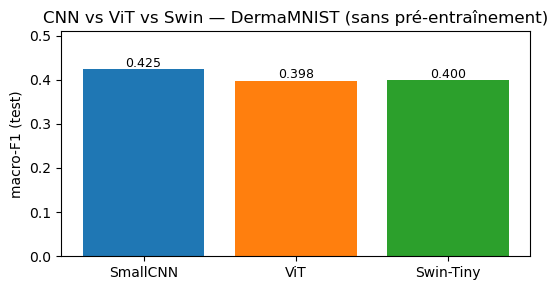

In [16]:
rows = [("SmallCNN (conv)", cnn, f1_cnn),
        ("ViT (from scratch)", vit, f1_test),
        ("Swin-Tiny (from scratch)", swin, f1_swin)]
print(f"{'Modèle':<26}{'macro-F1 test':>14}{'Params (M)':>13}{'Débit (img/s)':>15}")
print("-" * 68)
names, f1s = [], []
for name, model, f1 in rows:
    thr = throughput(model)
    print(f"{name:<26}{f1:>14.3f}{count_params(model)/1e6:>13.2f}{thr:>15.0f}")
    names.append(name.split(' ')[0]); f1s.append(f1)

plt.figure(figsize=(5.5, 3))
plt.bar(names, f1s, color=["C0", "C1", "C2"])
plt.ylabel("macro-F1 (test)"); plt.title("CNN vs ViT vs Swin — DermaMNIST (sans pré-entraînement)")
for i, v in enumerate(f1s): plt.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.ylim(0, max(f1s) * 1.2); plt.tight_layout(); plt.show()

### Écosystème pratique : `timm` & Hugging Face

En production on n'entraîne presque jamais un ViT *from scratch* : on **fine-tune** un backbone **pré-entraîné** (recettes du Module 2 — gel des couches, lr différentiel, OneCycle). La cellule ci-dessous **détecte** les bibliothèques (sans rien télécharger de lourd) et rappelle l'API canonique.

In [19]:
!pip install -U timm
import timm 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 6.8 MB/s  0:00:00 eta 0:00:01


In [20]:
try:    import timm; HAS_TIMM = True
except ImportError: HAS_TIMM = False
try:    import transformers; HAS_TRANSFORMERS = True
except ImportError: HAS_TRANSFORMERS = False
print(f"timm         : {'disponible' if HAS_TIMM else 'NON installé'}")
print(f"transformers : {'disponible' if HAS_TRANSFORMERS else 'NON installé'}")

print(r'''
# --- ViT/Swin pré-entraînés, tête remplacée (timm) ---
import timm
model = timm.create_model("vit_base_patch16_224",  pretrained=True, num_classes=7)
swin  = timm.create_model("swin_base_patch4_window7_224", pretrained=True, num_classes=7)
for p in model.blocks[:8].parameters():   # gel partiel + OneCycleLR (cf. Module 2)
    p.requires_grad = False

# --- SegFormer prêt à l'emploi (Hugging Face) ---
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
name  = "nvidia/segformer-b2-finetuned-ade-512-512"
proc  = SegformerImageProcessor.from_pretrained(name)
seg   = SegformerForSemanticSegmentation.from_pretrained(name)
logits = seg(**proc(images=img, return_tensors="pt")).logits   # (B,K,H/4,W/4)
mask   = logits.argmax(1)
''')
print("Note : nos implémentations 'from scratch' reproduisent exactement ces architectures.")

timm         : disponible
transformers : disponible

# --- ViT/Swin pré-entraînés, tête remplacée (timm) ---
import timm
model = timm.create_model("vit_base_patch16_224",  pretrained=True, num_classes=7)
swin  = timm.create_model("swin_base_patch4_window7_224", pretrained=True, num_classes=7)
for p in model.blocks[:8].parameters():   # gel partiel + OneCycleLR (cf. Module 2)
    p.requires_grad = False

# --- SegFormer prêt à l'emploi (Hugging Face) ---
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
name  = "nvidia/segformer-b2-finetuned-ade-512-512"
proc  = SegformerImageProcessor.from_pretrained(name)
seg   = SegformerForSemanticSegmentation.from_pretrained(name)
logits = seg(**proc(images=img, return_tensors="pt")).logits   # (B,K,H/4,W/4)
mask   = logits.argmax(1)

Note : nos implémentations 'from scratch' reproduisent exactement ces architectures.


## Partie X — Sauvegarde des modèles

Convention du dépôt : `<arch>_<dataset>_best.pt` dans `./checkpoints/`. Ces poids serviront au **TP 12** (export TorchScript / ONNX du ViT).

In [21]:
def save_ckpt(model, name, extra=None):
    payload = {"model_state_dict": model.state_dict()}
    if extra: payload.update(extra)
    path = CKPT_DIR / name
    torch.save(payload, path)
    print(f"OK {path}  ({path.stat().st_size/1e6:.1f} Mo)")

save_ckpt(vit,  "vit_dermamnist_best.pt",       {"img": IMG_SIZE, "patch": PATCH, "dim": 128, "depth": 6, "heads": 4})
save_ckpt(swin, "swin_dermamnist_best.pt",      {"img": IMG_SIZE})
save_ckpt(segm, "segformer_dermamnist_best.pt", {"task": "segmentation lésion (pseudo-masques Otsu)"})

OK checkpoints/vit_dermamnist_best.pt  (4.9 Mo)
OK checkpoints/swin_dermamnist_best.pt  (1.4 Mo)
OK checkpoints/segformer_dermamnist_best.pt  (0.5 Mo)


## Partie XI — Exercices d'application

### Exercice 1 — Efficacité en données (la règle de I.7)
Réentraînez `ViT` et `SmallCNN` sur un **sous-échantillon** du train (par `Subset` : 500, puis 1500, puis tout) à budget d'epochs égal, et tracez **macro-F1 vs taille du train** pour les deux. À quelle taille le ViT rattrape-t-il le CNN ? Le résultat confirme-t-il « dataset $<$ 10k $\Rightarrow$ CNN $>$ ViT » ?

### Exercice 2 — Taille des patchs
Faites varier `PATCH` $\in\{4, 7, 14\}$ (donc $N\in\{49,16,4\}$). Pour chaque valeur : macro-F1, nombre de paramètres, **débit**, et la granularité des cartes d'*attention rollout*. Reliez le coût observé à la complexité $O(N^2)$.

### Exercice 3 — Lecture `[CLS]` vs *mean-pooling*
Remplacez la décision sur le token `[CLS]` par la **moyenne des tokens de patchs** (`x.mean(1)` au lieu de `x[:, 0]`). Comparez macro-F1 et cartes d'attention. Le `[CLS]` est-il indispensable ?

### Exercice 4 — Distance d'attention moyenne
Pour chaque couche, calculez la **distance d'attention moyenne** (distance entre patchs, pondérée par les poids d'attention). Montrez que les **premières** couches mélangent déjà local **et** global — contrairement à un CNN purement local. (Indice : réutilisez `blk.last_attn`.)

### Exercice 5 — Swin : ablation du décalage
Mettez **tous** les `shift` à 0 (uniquement W-MSA, jamais SW-MSA) et réentraînez `SwinTiny`. Mesurez la chute de macro-F1 et expliquez : sans décalage, les fenêtres **ne communiquent jamais**. Visualisez l'absence de circulation d'information aux frontières.

### Exercice 6 — SegFormer : ratio $R$ et fonction de perte
(a) Faites varier le ratio de réduction $R\in\{1,2,4\}$ ($R=1$ = attention complète) : Dice **vs** débit. (b) Entraînez avec **BCE seule** (sans Dice) : comment évolue le Dice sur un masque déséquilibré ? Pourquoi le terme **Dice** aide-t-il quand la lésion est minoritaire ?

### Exercice 7 — Le réflexe « transfer learning » du Module 2
Installez `timm`, chargez `vit_base_patch16_224` **pré-entraîné**, remplacez la tête (7 classes), redimensionnez DermaMNIST en $224^2$ et fine-tunez (gel partiel, lr différentiel, `OneCycleLR`). Quantifiez l'écart de macro-F1 avec votre ViT *from scratch* : c'est tout l'intérêt du pré-entraînement annoncé en I.1 / I.7.

---

## Synthèse — API PyTorch des Vision Transformers

| Concept | API PyTorch |
|---|---|
| Patch embedding | `nn.Conv2d(C, d, P, stride=P)` (≡ `nn.Unfold`) |
| Token `[CLS]` + position | `nn.Parameter(torch.zeros(1,1,d))` / `nn.Parameter(torch.zeros(1,N+1,d))` |
| Self-attention (primitive) | `F.scaled_dot_product_attention(q, k, v)` (PyTorch ≥ 2.0) |
| Attention multi-têtes | `nn.MultiheadAttention(d, h, batch_first=True)` |
| Bloc encodeur pré-norm | `nn.TransformerEncoderLayer(d, h, norm_first=True)` |
| GELU / expansion ×4 | `nn.GELU()` ; MLP $d \to 4d \to d$ |
| Fenêtres Swin / décalage | `view` + `permute` ; `torch.roll` + masque d'attention |
| Biais de position relatif | `nn.Parameter` indexé par coordonnées relatives |
| Attention à séquence réduite | `nn.Conv2d(d, d, R, stride=R)` sur $K, V$ (SegFormer) |
| Mix-FFN | `nn.Conv2d(h, h, 3, groups=h)` *depthwise* dans le MLP |
| Décodeur tout-MLP | `Conv1×1` par échelle + `F.interpolate` + fusion |
| Carte d'attention (rollout) | hook sur le softmax ; produit des $\tfrac12 A + \tfrac12 I$ |
| Backbones pré-entraînés | `timm.create_model(..., pretrained=True, num_classes=K)` |
| SegFormer prêt à l'emploi | `transformers.SegformerForSemanticSegmentation` |
| Métriques segmentation | `torchmetrics.JaccardIndex` (mIoU) / Dice |

---

*Fin du TP 11 — **Module 4**.* **TP 12** : *Déploiement — TorchScript & ONNX* (sérialisation, export, ONNX Runtime, quantification), où l'on exportera le **ViT** sauvegardé ici.